# Heart Disease Prediction using AI and ML

## 1. Importing all the necessary libraries

In [42]:
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


print("Libraries imported successfully.")


Libraries imported successfully.


### Next...

## 2. Loading the dataset

In [43]:
# File path to the dataset
dataset_path = 'heart_disease.csv'

# Reading the data into a DataFrame
heart_df = pd.read_csv(dataset_path)

# Display the dataset structure
print("\nDataset Information:")
print(heart_df.info())

# Display the shape of the dataset
print(f"\nThe dataset contains {heart_df.shape[0]} rows and {heart_df.shape[1]} columns.")

# display the first 15 data from the dataset
heart_df.head(15)



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   cp         303 non-null    int64  
 3   trestbps   303 non-null    int64  
 4   chol       303 non-null    int64  
 5   fbs        303 non-null    int64  
 6   restecg    303 non-null    int64  
 7   thalach    303 non-null    int64  
 8   exang      303 non-null    int64  
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    int64  
 11  ca         303 non-null    int64  
 12  thal       303 non-null    int64  
 13  target     303 non-null    int64  
 14  smoking    303 non-null    object 
 15  drinking   303 non-null    object 
 16  asthma     303 non-null    object 
 17  kidneydis  303 non-null    object 
 18  skincan    303 non-null    object 
dtypes: float64(1), int64(13), ob

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,smoking,drinking,asthma,kidneydis,skincan
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,No,Yes,Yes,No,Yes
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Yes,No,No,No,Yes
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,No,Yes,Yes,Yes,No
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,No,Yes,Yes,Yes,No
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Yes,Yes,No,No,Yes
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1,Yes,No,Yes,No,Yes
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1,No,No,No,No,No
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1,No,Yes,Yes,No,No
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1,Yes,Yes,Yes,Yes,Yes
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1,Yes,Yes,No,Yes,Yes


### Next...

## 3. Exploratory Data Analysis (EDA)


### 3.1. Statistical Summary

In [44]:
# Show basic statistics for numerical columns
print("\nStatistical Summary of Numerical Features:")
print(heart_df.describe())

# Check unique values in categorical columns
categorical_columns = heart_df.select_dtypes(include=['object', 'category']).columns
print("\nUnique Values in Categorical Columns:")
for col in categorical_columns:
    print(f"{col}: {heart_df[col].unique()}")



Statistical Summary of Numerical Features:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.39934

### 3.2. Target Variable Distribution

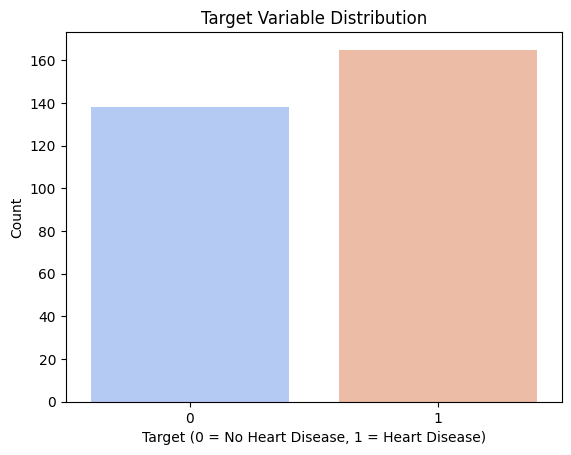

In [45]:
# Visualize the target variable distribution
sns.countplot(x='target', data=heart_df, palette='coolwarm')
plt.title("Target Variable Distribution")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Count")
plt.show()


### 3.3. Data Distribution

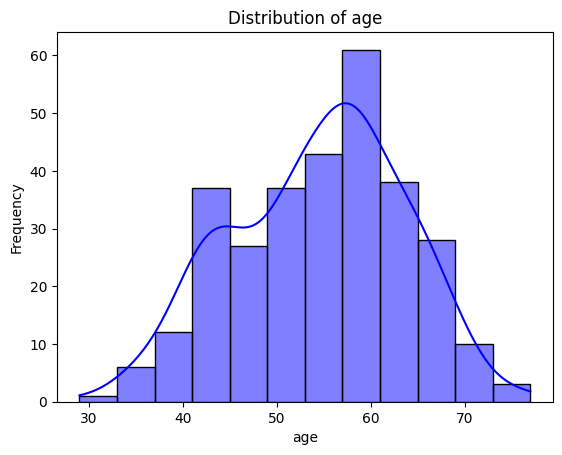

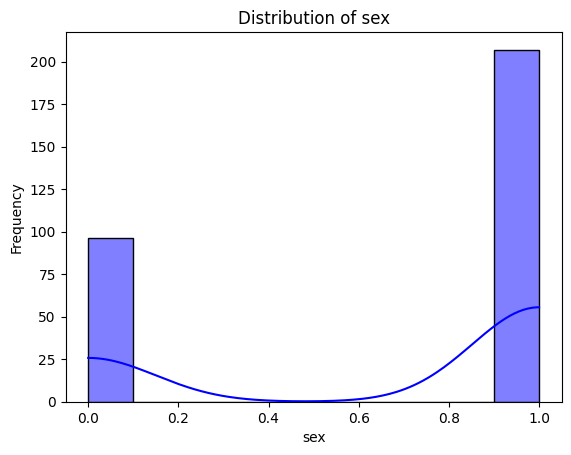

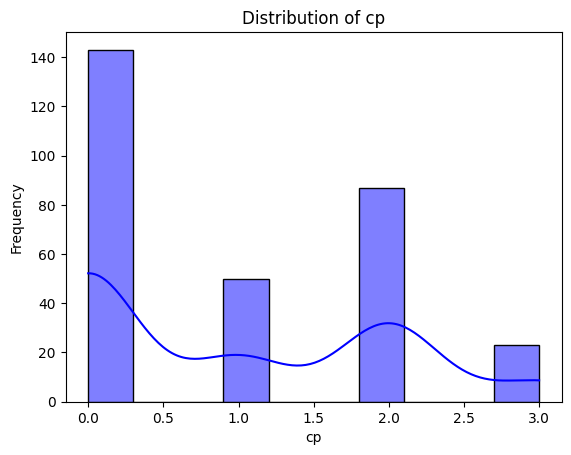

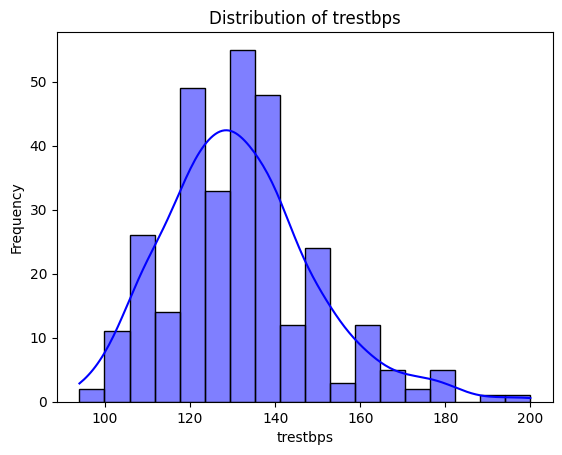

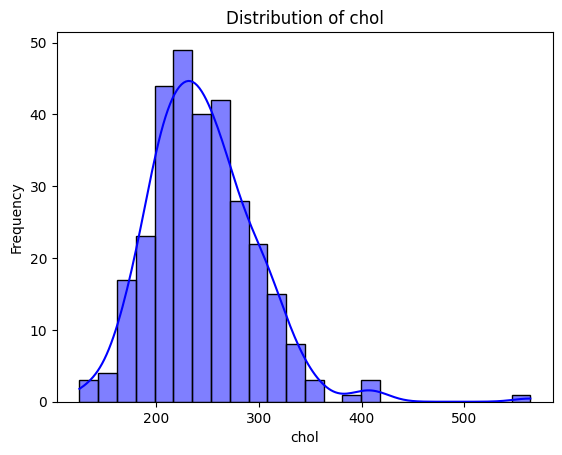

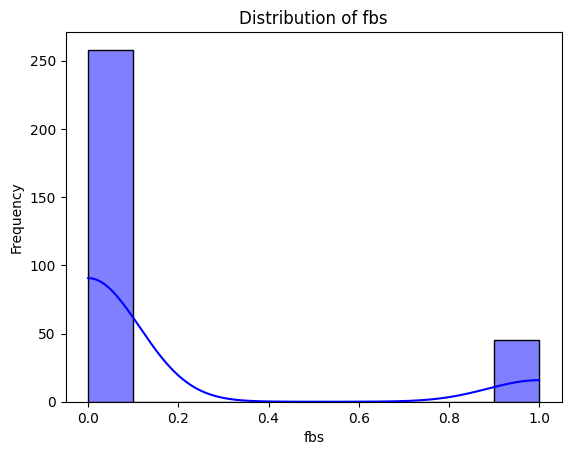

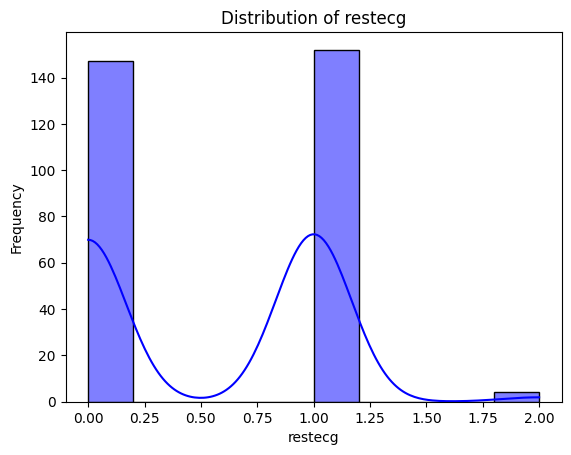

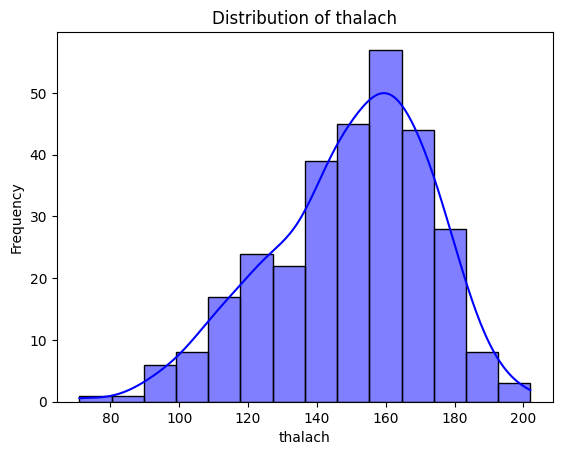

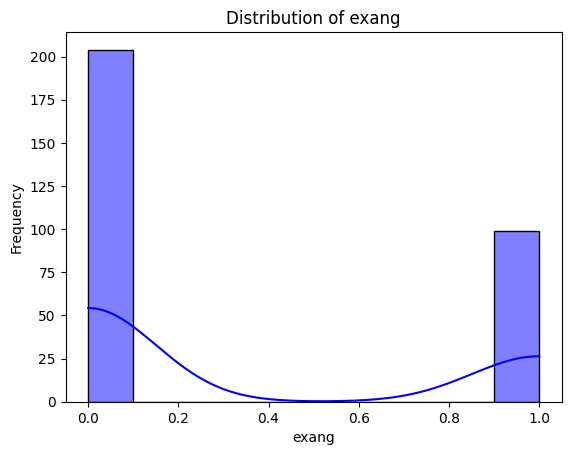

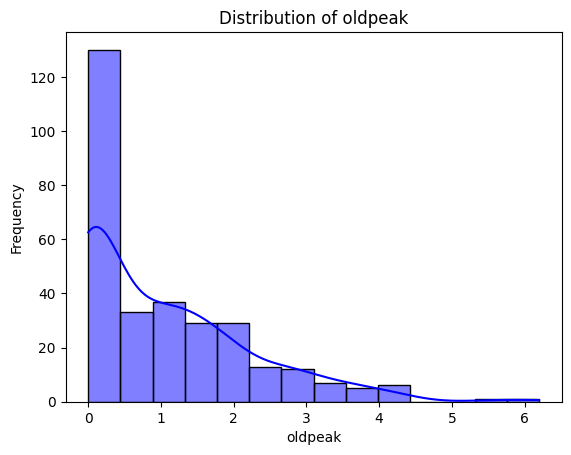

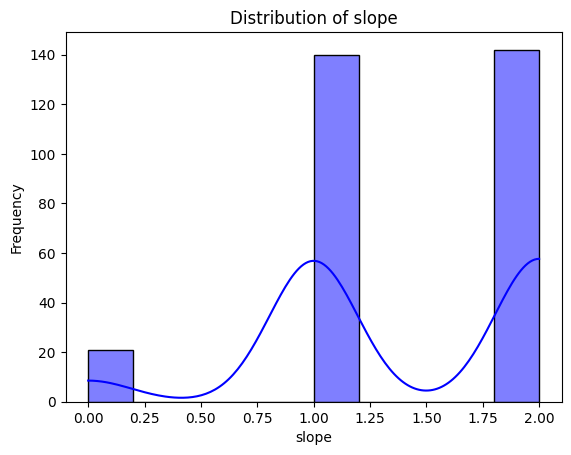

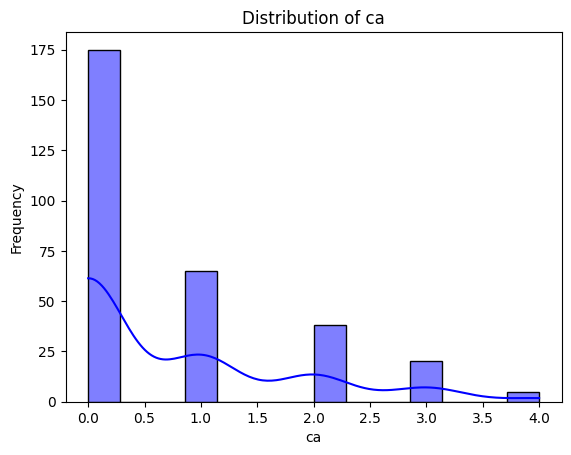

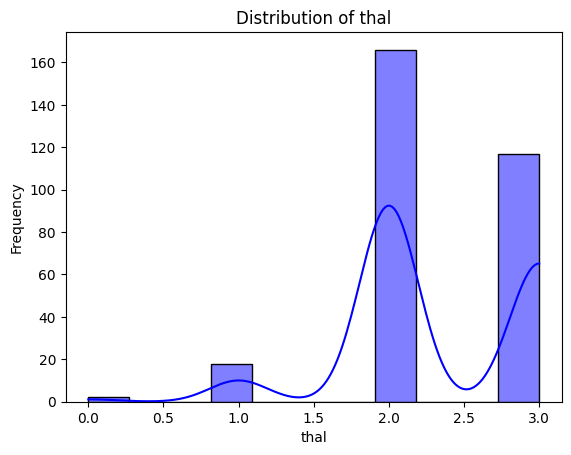

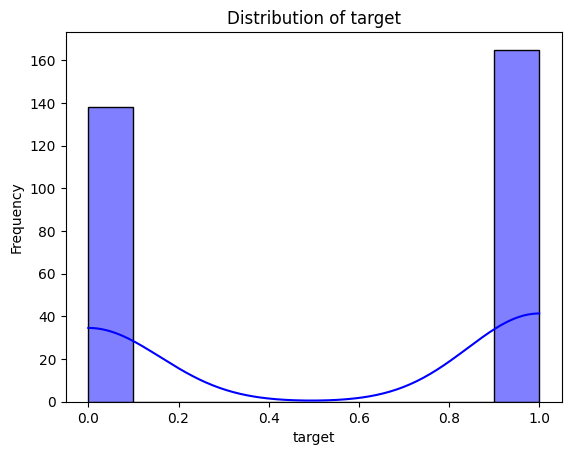

In [26]:
# Plot histograms for numerical features
numeric_cols = heart_df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    sns.histplot(data=heart_df, x=col, kde=True, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


### 3.5. Correlation Analysis

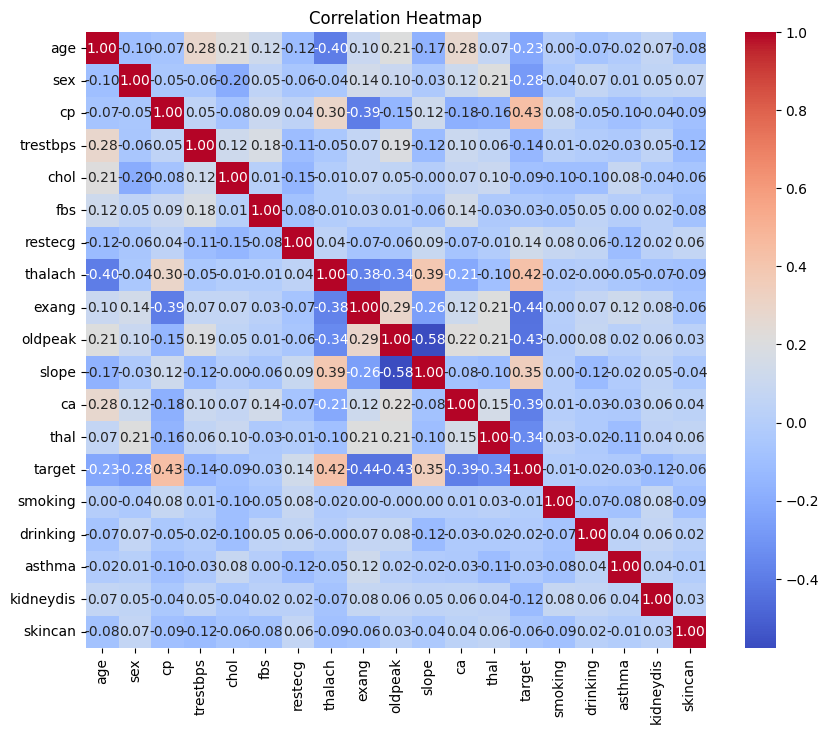

In [27]:
# Step 1: Encode categorical columns if they are not already numeric
categorical_columns = heart_df.select_dtypes(include=['object', 'category']).columns
if not categorical_columns.empty:
    heart_df[categorical_columns] = heart_df[categorical_columns].apply(lambda col: pd.factorize(col)[0])

# Step 2: Select only numeric columns for correlation
numeric_cols = heart_df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = heart_df[numeric_cols].corr()

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### 3.5.  Relationship Between Features and Target

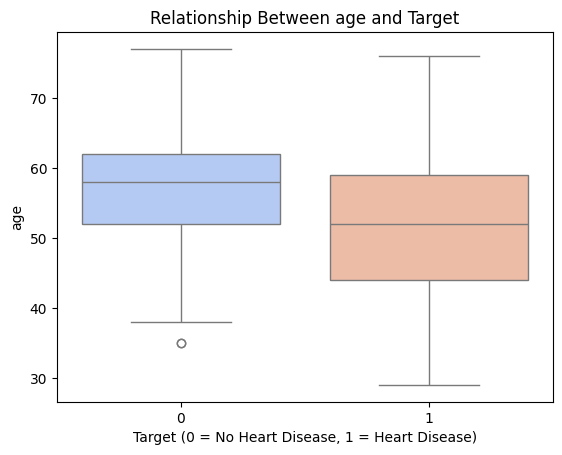

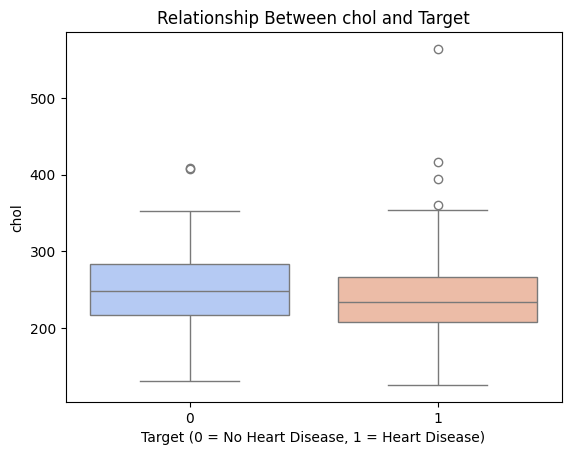

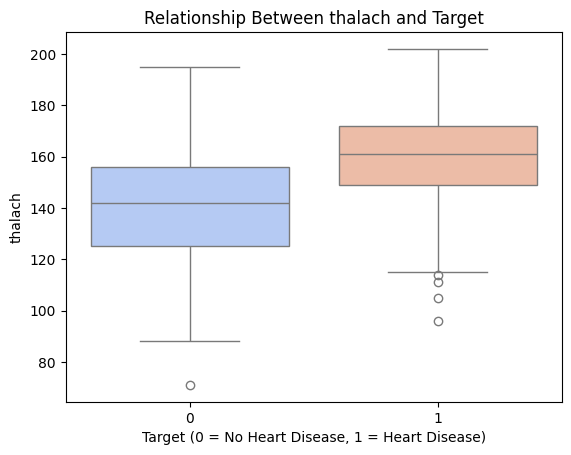

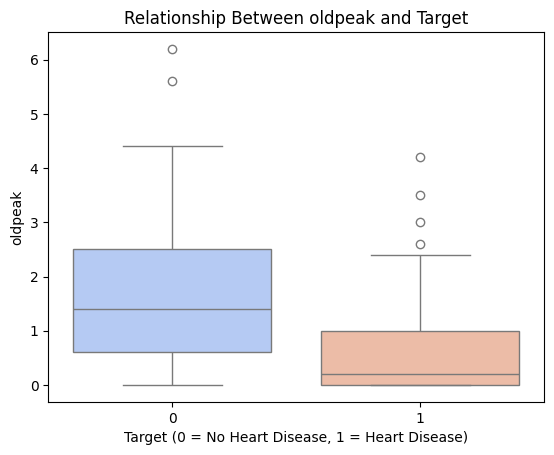

In [28]:
# Visualize relationships between key features and the target variable
important_features = ['age', 'chol', 'thalach', 'oldpeak']
for col in important_features:
    sns.boxplot(x='target', y=col, data=heart_df, palette='coolwarm')
    plt.title(f"Relationship Between {col} and Target")
    plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
    plt.ylabel(col)
    plt.show()


### Next...

## 4. Data Cleaning and Preprocessing

### 4.1. Handling Missing Values

In [56]:
# Check and fill missing values
print("\nMissing Values Before Handling:")
print(heart_df.isnull().sum())

# Fill missing values
for col in numeric_cols:
    if heart_df[col].isnull().sum() > 0:
        heart_df[col].fillna(heart_df[col].mean(), inplace=True)

for col in categorical_columns:
    if heart_df[col].isnull().sum() > 0:
        heart_df[col].fillna(heart_df[col].mode()[0], inplace=True)

print("\nMissing Values After Handling:")
print(heart_df.isnull().sum())



Missing Values Before Handling:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
target       0
smoking      0
drinking     0
asthma       0
kidneydis    0
skincan      0
dtype: int64

Missing Values After Handling:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
target       0
smoking      0
drinking     0
asthma       0
kidneydis    0
skincan      0
dtype: int64


### 4.2. Removing duplicates

In [57]:
# Check and remove duplicates
print(f"\nDuplicate Rows Before Removal: {heart_df.duplicated().sum()}")
heart_df.drop_duplicates(inplace=True)
print(f"Duplicate Rows After Removal: {heart_df.duplicated().sum()}")



Duplicate Rows Before Removal: 0
Duplicate Rows After Removal: 0


### 4.3. Encoding and Scaling

In [58]:
# Encode categorical columns
encoder = OrdinalEncoder()
heart_df[categorical_columns] = encoder.fit_transform(heart_df[categorical_columns])

# Scale numerical columns
scaler = StandardScaler()
heart_df[numeric_cols] = scaler.fit_transform(heart_df[numeric_cols])

# Display preprocessed dataset
print("\nSample of Preprocessed Dataset:")
print(heart_df.head())



Sample of Preprocessed Dataset:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.952197  0.681005  1.973123  0.763956 -0.256334  2.394438 -1.005832   
1 -1.915313  0.681005  1.002577 -0.092738  0.072199 -0.417635  0.898962   
2 -1.474158 -1.468418  0.032031 -0.092738 -0.816773 -0.417635 -1.005832   
3  0.180175  0.681005  0.032031 -0.663867 -0.198357 -0.417635  0.898962   
4  0.290464 -1.468418 -0.938515 -0.663867  2.082050 -0.417635  0.898962   

    thalach     exang   oldpeak     slope        ca      thal    target  \
0  0.015443 -0.696631  1.087338 -2.274579 -0.714429 -2.148873  0.914529   
1  1.633471 -0.696631  2.122573 -2.274579 -0.714429 -0.512922  0.914529   
2  0.977514 -0.696631  0.310912  0.976352 -0.714429 -0.512922  0.914529   
3  1.239897 -0.696631 -0.206705  0.976352 -0.714429 -0.512922  0.914529   
4  0.583939  1.435481 -0.379244  0.976352 -0.714429 -0.512922  0.914529   

    smoking  drinking    asthma  kidneydis   skincan  
0 -1.00330

### Next...

## 5. Train-Test Split

In [59]:
# Split features and target variable
X = heart_df.drop('target', axis=1)
# Ensure the target is integer
y = heart_df['target'].astype(int)  

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")



Training Set: (212, 18)
Testing Set: (91, 18)


### Next...

## 6. Model Training and Evaluation

## 6.1. SVM Model


SVM Accuracy (Before Tuning): 0.7802197802197802

SVM Classification Report (Before Tuning):
              precision    recall  f1-score   support

          -1       0.74      0.78      0.76        41
           0       0.81      0.78      0.80        50

    accuracy                           0.78        91
   macro avg       0.78      0.78      0.78        91
weighted avg       0.78      0.78      0.78        91



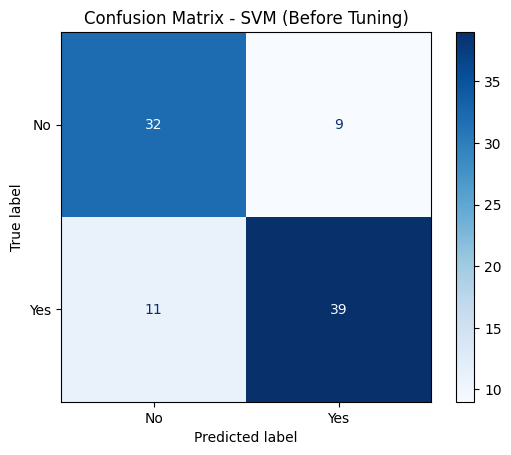


SVM Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

SVM Accuracy (After Tuning): 0.7802197802197802

SVM Classification Report (After Tuning):
              precision    recall  f1-score   support

          -1       0.76      0.76      0.76        41
           0       0.80      0.80      0.80        50

    accuracy                           0.78        91
   macro avg       0.78      0.78      0.78        91
weighted avg       0.78      0.78      0.78        91



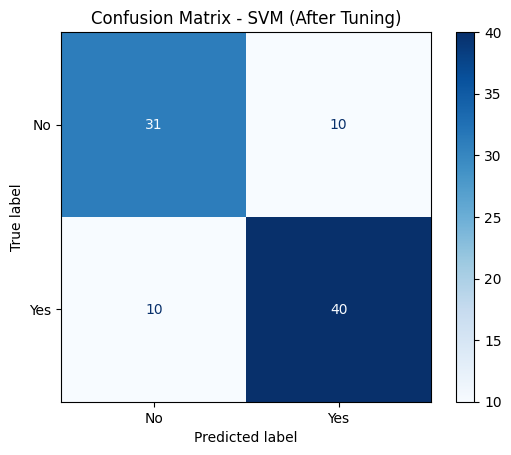

In [60]:
# Initialize SVM (before tuning)
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
svm_predictions = svm.predict(X_test)

# Evaluate SVM (before tuning)
print("\nSVM Accuracy (Before Tuning):", accuracy_score(y_test, svm_predictions))
print("\nSVM Classification Report (Before Tuning):")
print(classification_report(y_test, svm_predictions))

# Confusion Matrix (Before Tuning)
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Confusion Matrix - SVM (Before Tuning)")
plt.show()

# Hyperparameter tuning for SVM
svm_params = {
    'C': [0.1, 1, 10, 100],         # Regularization strength
    'kernel': ['linear', 'rbf'],    # Linear and Radial Basis Function kernels
    'gamma': ['scale', 'auto']      # Kernel coefficient for 'rbf'
}

svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5)
svm_grid.fit(X_train, y_train)

# Get the best SVM model
best_svm = svm_grid.best_estimator_
svm_tuned_predictions = best_svm.predict(X_test)

# Evaluate SVM (after tuning)
print("\nSVM Best Parameters:", svm_grid.best_params_)
print("\nSVM Accuracy (After Tuning):", accuracy_score(y_test, svm_tuned_predictions))
print("\nSVM Classification Report (After Tuning):")
print(classification_report(y_test, svm_tuned_predictions))

# Confusion Matrix (After Tuning)
ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Confusion Matrix - SVM (After Tuning)")
plt.show()


### Next...

## 6.2. K-Nearest Neighbors (KNN) Model


KNN Accuracy (Before Tuning): 0.7692307692307693

KNN Classification Report (Before Tuning):
              precision    recall  f1-score   support

          -1       0.75      0.73      0.74        41
           0       0.78      0.80      0.79        50

    accuracy                           0.77        91
   macro avg       0.77      0.77      0.77        91
weighted avg       0.77      0.77      0.77        91


KNN Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}

KNN Accuracy (After Tuning): 0.8131868131868132

KNN Classification Report (After Tuning):
              precision    recall  f1-score   support

          -1       0.80      0.78      0.79        41
           0       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



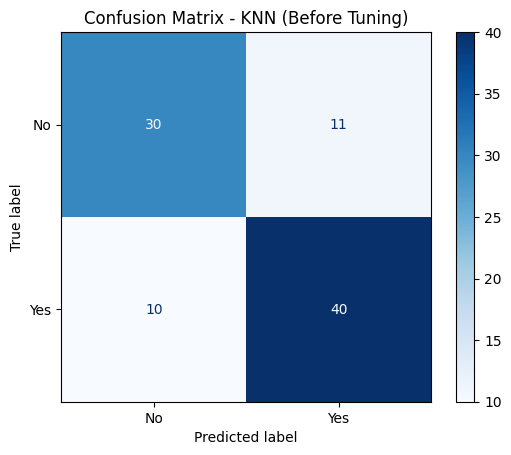

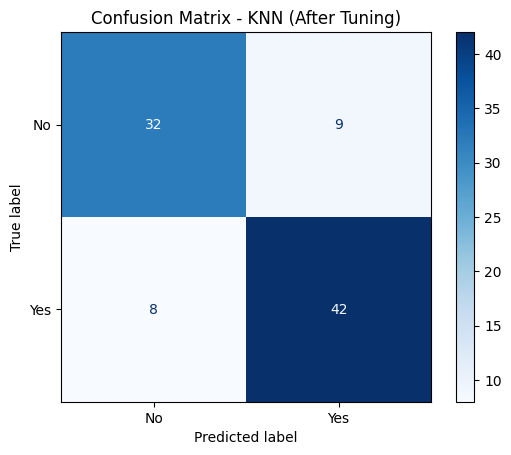

In [61]:
# Initialize KNN model (before tuning)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)

# Evaluate KNN (before tuning)
print("\nKNN Accuracy (Before Tuning):", accuracy_score(y_test, knn_predictions))
print("\nKNN Classification Report (Before Tuning):")
print(classification_report(y_test, knn_predictions))

# Hyperparameter tuning for KNN
knn_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train, y_train)

# Best model after tuning
best_knn = knn_grid.best_estimator_
knn_tuned_predictions = best_knn.predict(X_test)

# Evaluate KNN (after tuning)
print("\nKNN Best Parameters:", knn_grid.best_params_)
print("\nKNN Accuracy (After Tuning):", accuracy_score(y_test, knn_tuned_predictions))
print("\nKNN Classification Report (After Tuning):")
print(classification_report(y_test, knn_tuned_predictions))

# Confusion Matrix (Before Tuning)
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Confusion Matrix - KNN (Before Tuning)")
plt.show()

# Confusion Matrix (After Tuning)
ConfusionMatrixDisplay.from_estimator(best_knn, X_test, y_test, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Confusion Matrix - KNN (After Tuning)")
plt.show()


### Next...

### 6.3. Random Forest Model


Random Forest Accuracy (Before Tuning): 0.8241758241758241

Random Forest Classification Report (Before Tuning):
              precision    recall  f1-score   support

          -1       0.80      0.80      0.80        41
           0       0.84      0.84      0.84        50

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91



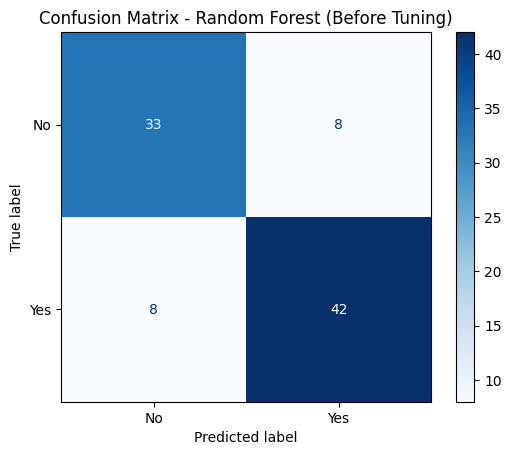


Random Forest Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Accuracy (After Tuning): 0.8241758241758241

Random Forest Classification Report (After Tuning):
              precision    recall  f1-score   support

          -1       0.80      0.80      0.80        41
           0       0.84      0.84      0.84        50

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91



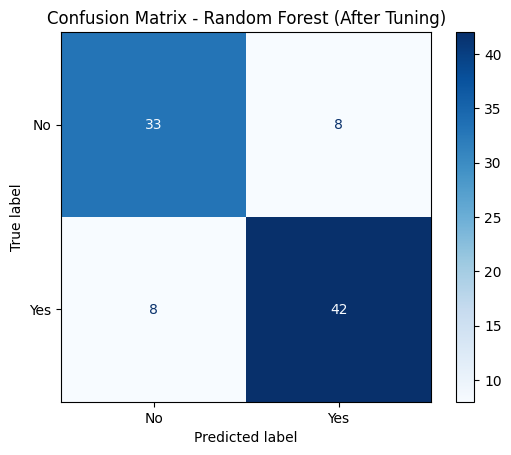

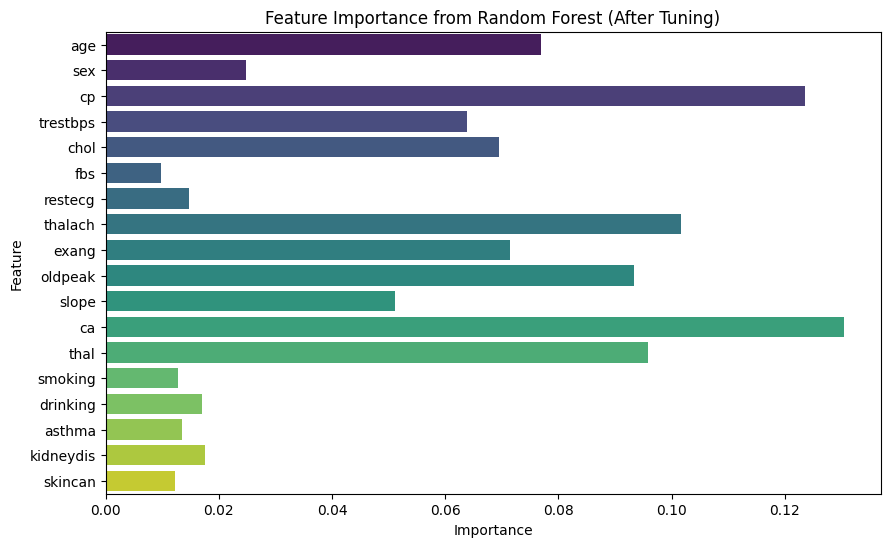

In [62]:
# Initialize Random Forest (before tuning)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)

# Evaluate Random Forest (before tuning)
print("\nRandom Forest Accuracy (Before Tuning):", accuracy_score(y_test, rf_predictions))
print("\nRandom Forest Classification Report (Before Tuning):")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix (Before Tuning)
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Before Tuning)")
plt.show()

# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, None],     # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]  # Minimum number of samples required to split a node
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train, y_train)

# Get the best Random Forest model
best_rf = rf_grid.best_estimator_
rf_tuned_predictions = best_rf.predict(X_test)

# Evaluate Random Forest (after tuning)
print("\nRandom Forest Best Parameters:", rf_grid.best_params_)
print("\nRandom Forest Accuracy (After Tuning):", accuracy_score(y_test, rf_tuned_predictions))
print("\nRandom Forest Classification Report (After Tuning):")
print(classification_report(y_test, rf_tuned_predictions))

# Confusion Matrix (After Tuning)
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Confusion Matrix - Random Forest (After Tuning)")
plt.show()

# Feature Importance (After Tuning)
plt.figure(figsize=(10, 6))
sns.barplot(x=best_rf.feature_importances_, y=X.columns, palette="viridis")
plt.title("Feature Importance from Random Forest (After Tuning)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


### Next...

## 7. Results Comparision


Model Comparison:
                           Model  Accuracy
0            SVM (Before Tuning)  0.780220
1             SVM (After Tuning)  0.780220
2            KNN (Before Tuning)  0.769231
3             KNN (After Tuning)  0.813187
4  Random Forest (Before Tuning)  0.824176
5   Random Forest (After Tuning)  0.824176


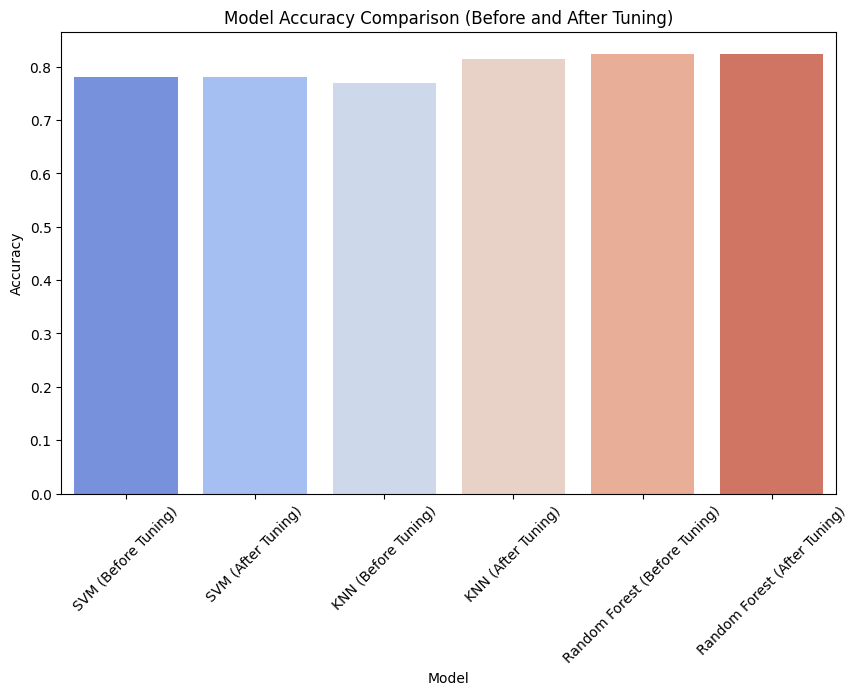

In [63]:
# Compare model results with before and after tuning
results = {
    "Model": [
        "SVM (Before Tuning)", "SVM (After Tuning)", 
        "KNN (Before Tuning)", "KNN (After Tuning)", 
        "Random Forest (Before Tuning)", "Random Forest (After Tuning)"
    ],
    "Accuracy": [
        accuracy_score(y_test, svm_predictions),        # SVM before tuning
        accuracy_score(y_test, svm_tuned_predictions),  # SVM after tuning
        accuracy_score(y_test, knn_predictions),        # KNN before tuning
        accuracy_score(y_test, knn_tuned_predictions),  # KNN after tuning
        accuracy_score(y_test, rf_predictions),         # Random Forest before tuning
        accuracy_score(y_test, rf_tuned_predictions)    # Random Forest after tuning
    ]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Visualize model performance
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="coolwarm")
plt.title("Model Accuracy Comparison (Before and After Tuning)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


### ...End...